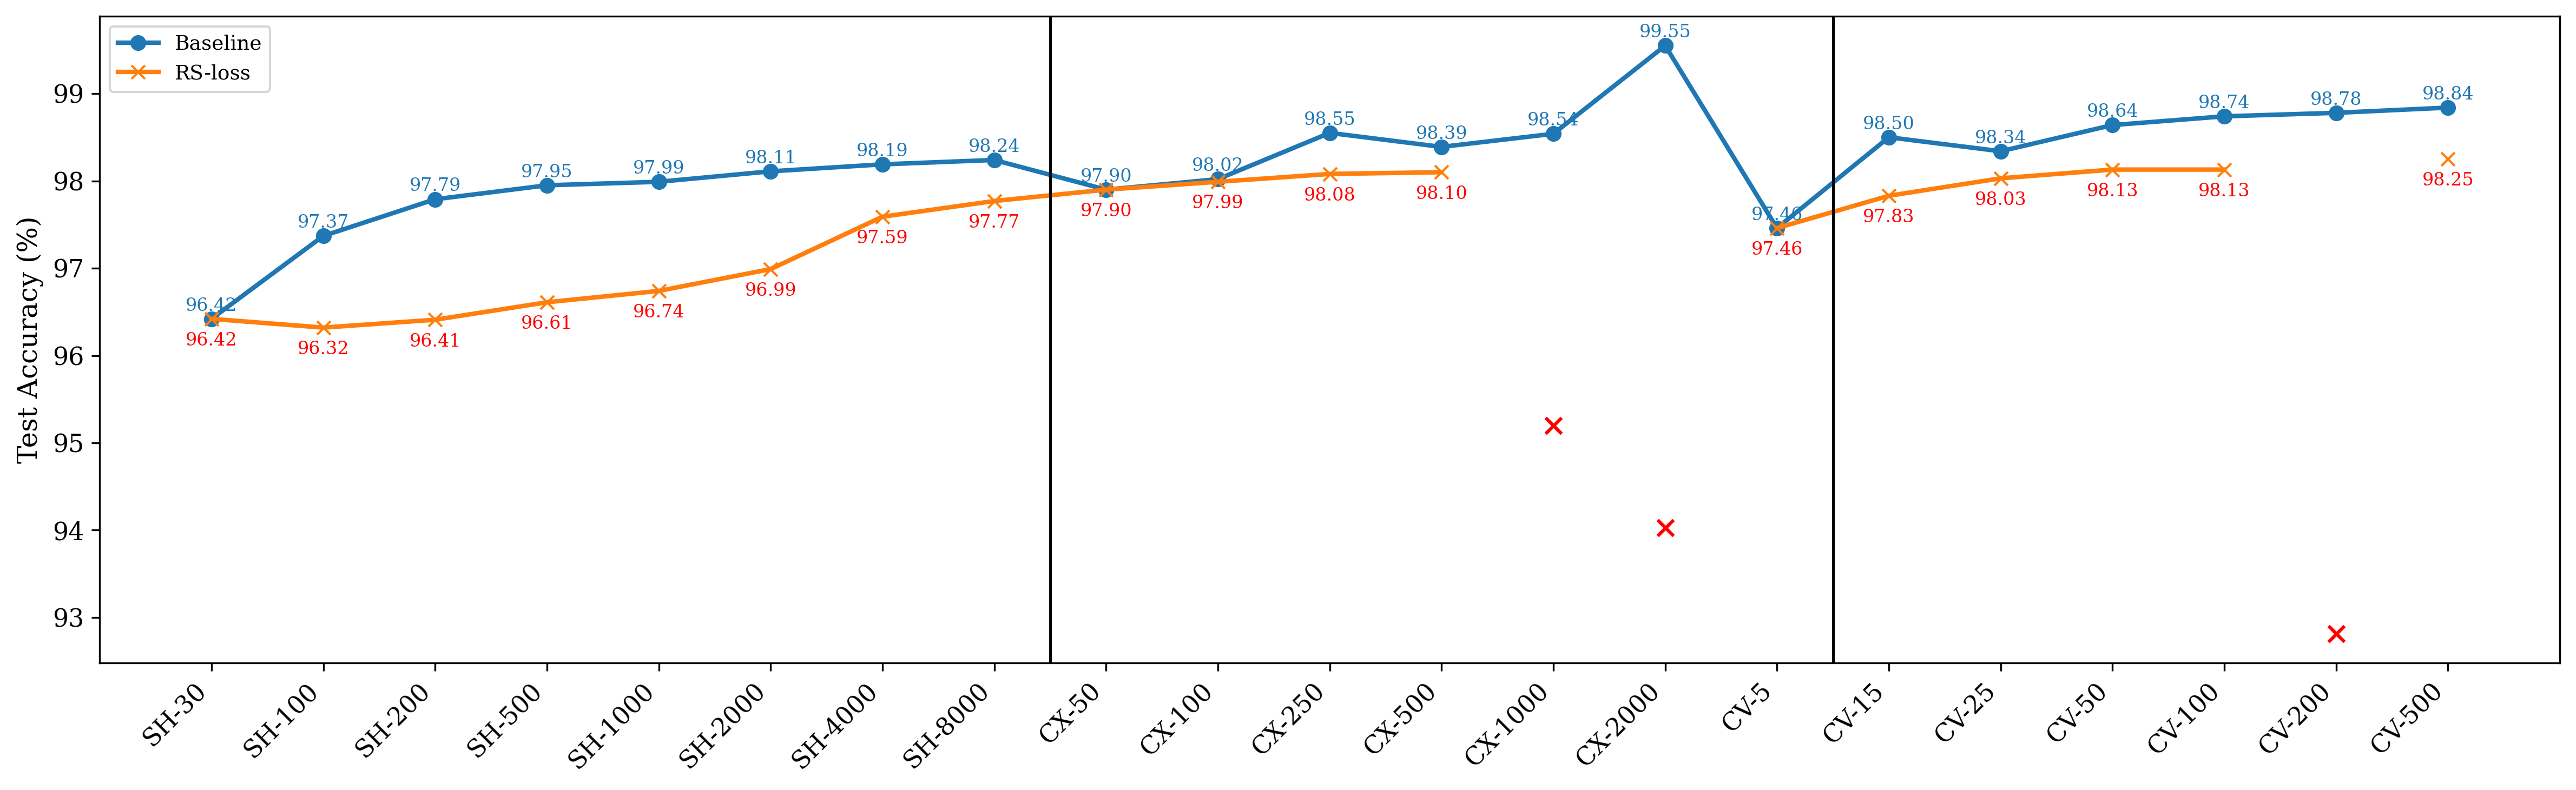

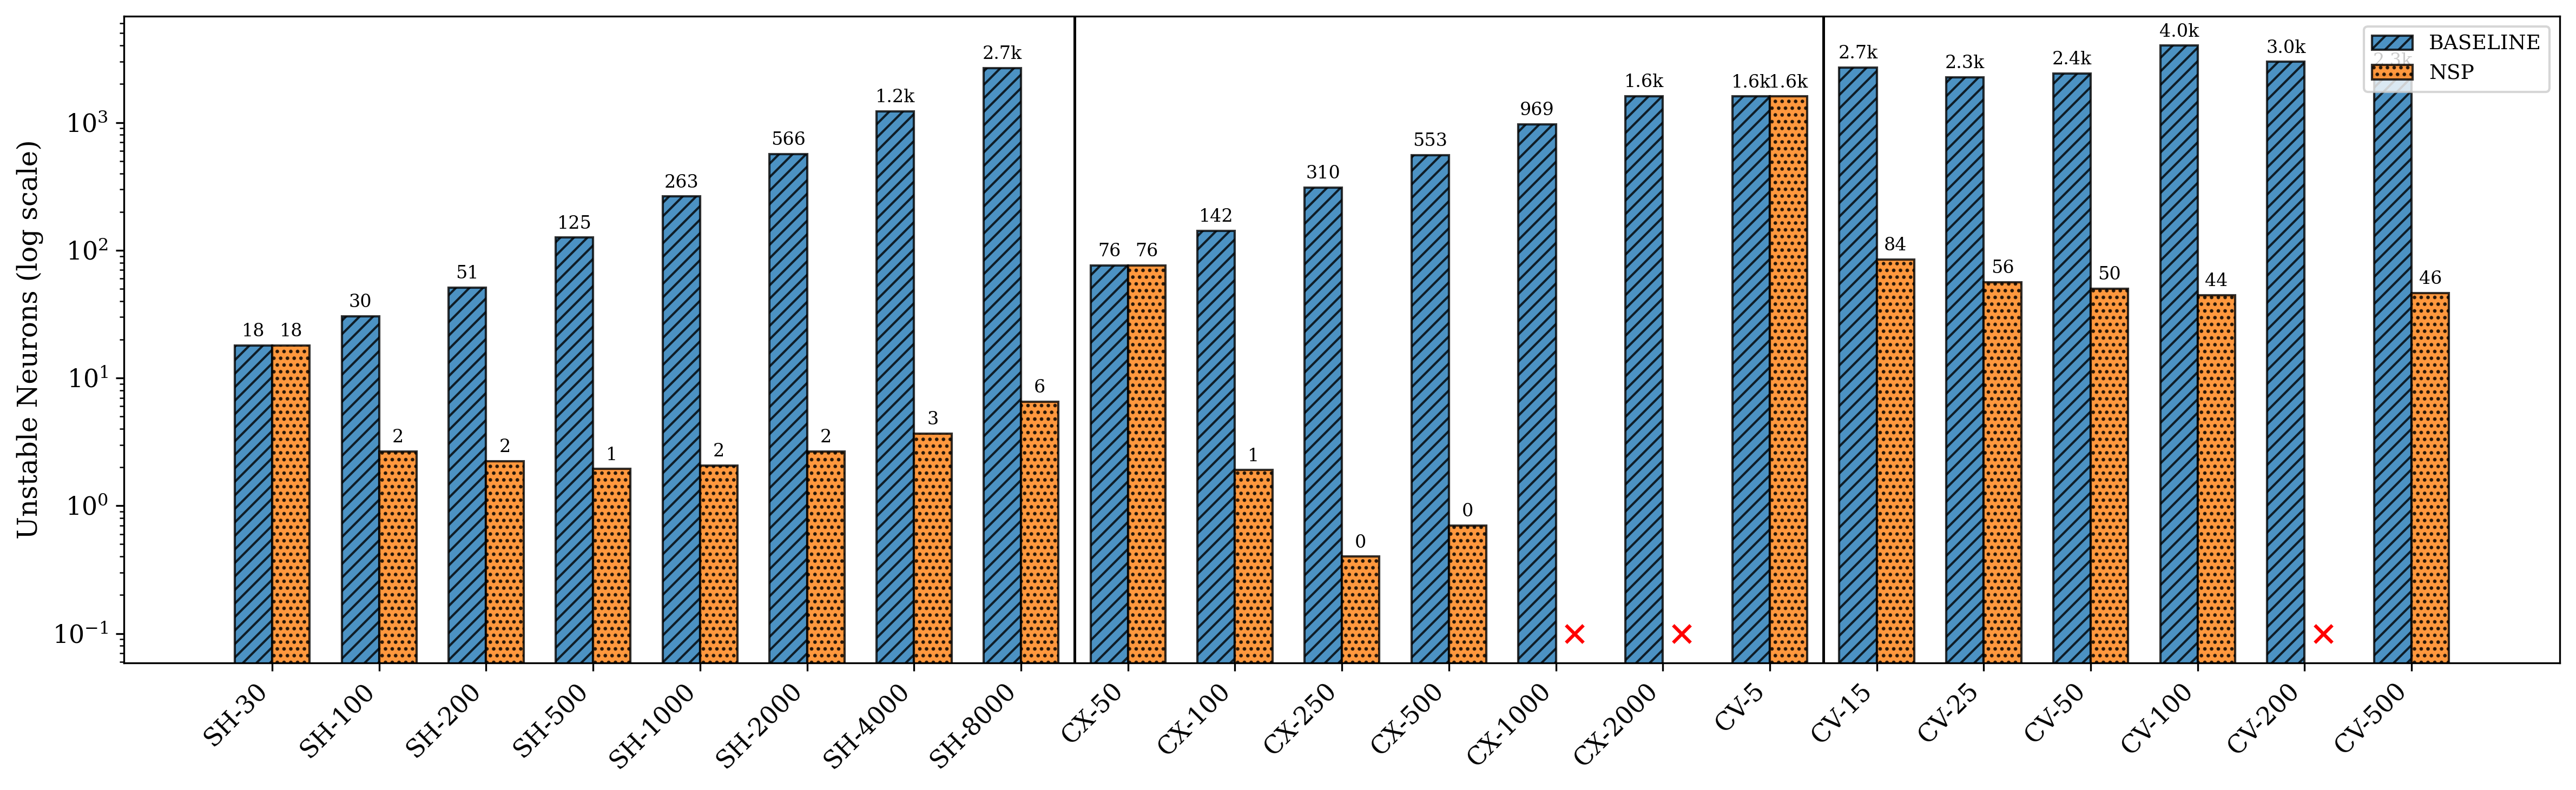

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# === DATI ===
arch_shallow = ["SH-30", "SH-100", "SH-200", "SH-500", "SH-1000", "SH-2000", "SH-4000", "SH-8000"]
acc_baseline_shallow = [96.42, 97.37, 97.79, 97.95, 97.99, 98.11, 98.19, 98.24]
acc_rs_shallow       = [96.42, 96.32, 96.41, 96.61, 96.74, 96.99, 97.59, 97.77]
unst_baseline_shallow = [18.02, 30.4, 51.1, 125.7, 263.3, 566.4, 1226.4, 2662.7]
unst_rs_shallow       = [18.02, 2.66, 2.23, 1.94, 2.06, 2.67, 3.68, 6.52]

arch_complex = ["CX-50", "CX-100", "CX-250", "CX-500", "CX-1000", "CX-2000"]
acc_baseline_complex = [97.9, 98.02, 98.55, 98.39, 98.54, 99.55]
acc_rs_complex       = [97.9, 97.99, 98.08, 98.10, np.nan, np.nan]
unst_baseline_complex = [76.1, 142.3, 310.3, 553.6, 969.2, 1604.4]
unst_rs_complex       = [76.1, 1.9, 0.4, 0.7, np.nan, np.nan]

arch_conv = ["CV-5", "CV-15", "CV-25", "CV-50", "CV-100", "CV-200", "CV-500"]
acc_baseline_conv = [97.46, 98.50, 98.34, 98.64, 98.74, 98.78, 98.84]
acc_rs_conv       = [97.46, 97.83, 98.03, 98.13, 98.13, np.nan, 98.25]
unst_baseline_conv = [1598.2, 2702.3, 2255.3, 2410.3, 3996.9, 2982.4, 2344.2]
unst_rs_conv       = [1598.2, 84.8, 56.0, 50.1, 44.4, np.nan, 46.1]

# === GRAFICO ACCURACY ===
def plot_accuracy_single():
    networks = [
        ("SH", arch_shallow, acc_baseline_shallow, acc_rs_shallow),
        ("CX", arch_complex, acc_baseline_complex, acc_rs_complex),
        ("CV", arch_conv, acc_baseline_conv, acc_rs_conv)
    ]

    x_positions = []
    labels = []
    offset = 0
    for _, arch, _, _ in networks:
        x_positions.extend([offset + i for i in range(len(arch))])
        labels.extend(arch)
        offset += len(arch)
    x_positions = np.array(x_positions)

    acc_base_all = np.concatenate([acc_baseline_shallow, acc_baseline_complex, acc_baseline_conv])
    acc_rs_all   = np.concatenate([acc_rs_shallow, acc_rs_complex, acc_rs_conv])

    plt.figure(figsize=(16,5))
    # Baseline
    plt.plot(x_positions, acc_base_all, 'o-', color='C0', label='Baseline', linewidth=2, markersize=6)
    # RS-loss con x rossa
    plt.plot(x_positions, acc_rs_all, 'x-', color='C1', label='RS-loss', linewidth=2, markersize=6)

    # x per punti NaN
    for xi, y in zip(x_positions, acc_rs_all):
        if np.isnan(y):
            plt.scatter(xi, plt.ylim()[0]*0.99, color='red', marker='x', s=50, zorder=10)

    plt.xticks(x_positions, labels, rotation=45, ha='right')
    plt.ylabel("Test Accuracy (%)")

    # Linee separatrici nere continue
    sep_positions = [len(arch_shallow)-0.5, len(arch_shallow)+len(arch_complex)+0.5]
    for pos in sep_positions:
        plt.axvline(x=pos, color='black', linestyle='-', linewidth=1.2)

    # Etichette valori
    for xi, y in zip(x_positions, acc_base_all):
        if not np.isnan(y):
            plt.text(xi, y + 0.05, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='C0')
    for xi, y in zip(x_positions, acc_rs_all):
        if not np.isnan(y):
            plt.text(xi, y - 0.15, f"{y:.2f}", ha='center', va='top', fontsize=8, color='red')

    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("accuracy_single.jpeg", dpi=300, format='jpeg')
    plt.show()

# === GRAFICO UNSTABLE NEURONS ===
def plot_unstable_single():
    networks = [
        ("SH", arch_shallow, unst_baseline_shallow, unst_rs_shallow),
        ("CX", arch_complex, unst_baseline_complex, unst_rs_complex),
        ("CV", arch_conv, unst_baseline_conv, unst_rs_conv)
    ]

    x_positions = []
    labels = []
    offset = 0
    for _, arch, _, _ in networks:
        x_positions.extend([offset + i for i in range(len(arch))])
        labels.extend(arch)
        offset += len(arch)
    x_positions = np.array(x_positions)

    unst_base_all = np.concatenate([unst_baseline_shallow, unst_baseline_complex, unst_baseline_conv])
    unst_rs_all   = np.concatenate([unst_rs_shallow, unst_rs_complex, unst_rs_conv])

    width = 0.35
    plt.figure(figsize=(16,5))

    # Baseline
    bars_base = plt.bar(x_positions - width/2, np.nan_to_num(unst_base_all), width,
                        color='C0', alpha=0.8, hatch='////', edgecolor='black', label='BASELINE')
    # RS-loss
    bars_rs   = plt.bar(x_positions + width/2, np.nan_to_num(unst_rs_all, nan=0), width,
                        color='C1', alpha=0.8, hatch='....', edgecolor='black', label='NSP')

    # x rosse sui NaN
    for xi, y in enumerate(unst_rs_all):
        if np.isnan(y):
            plt.scatter(x_positions[xi] + width/2, 0.1, color='red', marker='x', s=60, zorder=10)  # 0.1 per log scale

    plt.xticks(x_positions, labels, rotation=45, ha='right')
    plt.ylabel("Unstable Neurons (log scale)")
    plt.yscale("log")

    # Linee separatrici nere continue
    sep_positions = [len(arch_shallow)-0.5, len(arch_shallow)+len(arch_complex)+0.5]
    for pos in sep_positions:
        plt.axvline(x=pos, color='black', linestyle='-', linewidth=1.2)

    # Etichette sulle barre
    for bar in bars_base:
        h = bar.get_height()
        if h > 0:
            label = f"{h/1000:.1f}k" if h >= 1000 else f"{int(h)}"
            plt.text(bar.get_x() + bar.get_width()/2, h*1.1, label, ha='center', va='bottom', fontsize=8)
    for bar in bars_rs:
        h = bar.get_height()
        if h > 0:
            label = f"{h/1000:.1f}k" if h >= 1000 else f"{int(h)}"
            plt.text(bar.get_x() + bar.get_width()/2, h*1.1, label, ha='center', va='bottom', fontsize=8)

    plt.legend(loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("unstable_single.jpeg", dpi=300, format='jpeg')
    plt.show()

# === GENERA GRAFICI ===
plot_accuracy_single()
plot_unstable_single()
